# <u> **10-K Filing Stakeholder Engagement or Orientation NLP Analysis** </u>

### **Data Analysis Steps:**
- Download 10-K filings from the SEC EDGAR database.
- Extract relevant sections (e.g., Item 1: Business, Item 7: MD&A) using regex or document parsing tools (e.g., BeautifulSoup, PyPDF2).
- Preprocess text to remove boilerplate language and normalize terms.
- Apply LDA to identify stakeholder engagement topics (e.g., employee welfare, customer satisfaction).
- Use BERT-based sentiment analysis to classify the tone of stakeholder mentions (e.g., positive vs. neutral).
- Quantify engagement frequency and correlate with financial metrics like return on equity or ESG scores.

### **Analysis Challenges:**
- Boilerplate language may obscure specific stakeholder engagement signals.
- Stakeholder terms vary by industry, requiring custom dictionaries.
- Lengthy documents demand efficient processing (e.g., chunking).

### **Analysis Example:**
- A 10-K might state: “We prioritize employee engagement through diversity programs and training.” NLP can extract “employee engagement” and “diversity programs,” classify the sentiment as positive, and quantify the firm’s orientation toward employees.

### **Data Destription:**
- UNITED STATES - SECURITIES AND EXCHANGE COMMISSION - Washington, D.C. 20549 - FORM 10-K
- For the fiscal year ended December 31, 2025 - Tesla, Inc.
- https://www.sec.gov/Archives/edgar/data/1318605/000162828026003952/tsla-20251231.htm#i39f9a11fdbe840828cbaefa2e098ffa8_151

---

## **Importing Packages:**

In [38]:
from MyPackages import *


---

## **Download 10-K filings from the SEC EDGAR database:**

In [39]:
soup = web_text(url= 'https://www.sec.gov/Archives/edgar/data/1318605/000162828026003952/tsla-20251231.htm#i39f9a11fdbe840828cbaefa2e098ffa8_151')

lst = []

for i in soup.find_all('span'):
    lst.append(i.get_text(strip= True))

for i in range(len(lst)):
    print(i, ' - ', lst[i])

0  -  
1  -  UNITED STATES
2  -  SECURITIES AND EXCHANGE COMMISSION
3  -  Washington, D.C. 20549
4  -  FORM10-K
5  -  (Mark One)
6  -  x
7  -  ANNUAL REPORT PURSUANT TO SECTION 13 OR 15(d) OF THE SECURITIES EXCHANGE ACT OF 1934
8  -  For the fiscal year endedDecember 31, 2025
9  -  OR
10  -  o
11  -  TRANSITION REPORT PURSUANT TO SECTION 13 OR 15(d) OF THE SECURITIES EXCHANGE ACT OF 1934
12  -  For the transition period from _________ to _________
13  -  Commission File Number:001-34756
14  -  Tesla, Inc.
15  -  (Exact name of registrant as specified in its charter)
16  -  Texas
17  -  91-2197729
18  -  (State or other jurisdiction ofincorporation or organization)
19  -  (I.R.S. EmployerIdentification No.)
20  -  1 Tesla Road
21  -  Austin,Texas
22  -  78725
23  -  (Address of principal executive offices)
24  -  (Zip Code)
25  -  (512)516-8177
26  -  (Registrant’s telephone number, including area code)
27  -  Securities registered pursuant to Section 12(b) of the Act:
28  -  Title of e

In [40]:
df = {'text': lst}
df = pd.DataFrame(df)
df

,text
0,
1,UNITED STATES
2,SECURITIES AND EXCHANGE COMMISSION
3,"Washington, D.C. 20549"
4,FORM10-K
...,...
4874,"January 28, 2026"
4875,Kathleen Wilson-Thompson
4876,
4877,


> Downloaded and received all the text from Tesla Inc.'s annual 2025 10-K filing from https://www.sec.gov/. Also converted the list of text from the 10-K filing into a dataframe datatype format. Dataframes are much easier to work with using Panda's pre-made function, rather than nested for loops created from scratch for every operation on the text.

## **Extract relevant sections (e.g., Item 1: Business, Item 7: MD&A) using regex or document parsing tools (e.g., BeautifulSoup, PyPDF2). Preprocess text to remove boilerplate language and normalize terms:**

In [41]:
item1 = df.copy()
item7 = df.copy()

> Item 1 and item 7 will be extracted separately and then combined. First, item 1 will be found from the text and edited. Then the same operations will be done with Item 7.

In [42]:
start = item1[item1['text'].str.contains('ITEM 1. BUSINESS')].index[0]
end = item1[item1['text'].str.contains('reference into this Annual Report on Form 10-K.')].index[0]

item1 = item1[start: end + 1]

> The beginning and end indices of item 1 business section of the 10-K filing have been found, and the dataframe has been sliced to only hold the text between these two indices. Its important to note that when slicing lists, the code uses the inclusive-exclusive rule. Meaning, the beginning index line of text is included in the new list, and the ending index line of text is excluded from the new list. That is why ending index + 1 must be specified. The ending line of text must be included, not excluded.

In [43]:
item1 = item1[item1['text'].str.len() >= 70]

item1 = item1.reset_index()
item1 = item1.drop(labels= 'index', axis= 1)

> Removed unnecessary and meaningless text with no value in future analysis. Any lines of text that are less than 70 characters long have been removed. This mainly includes blank spaces, awkward one letter lines of text, and headings for sections of the document. The index for the dataframe has also been reset. Now the item 1 business section of the 10-K annual 2025 filing from Tesla is complete.

In [44]:
start = item7[item7['text'].str.contains('ITEM 7. MANAGEMENT’S DISCUSSION AND ANALYSIS OF FINANCIAL CONDITION AND RESULTS OF OPERATIONS')].index[0]
end = item7[item7['text'].str.contains('net of payment for related legal fees during the year ended December 31, 2025.')].index[0]

item7 = item7[start: end + 1]

> Next is the item 7 MD&A section of the 10-K filing extraction from the text. The beginning and ending indices have been found for item 7, and the lines of text have been sliced and added to a dataframe.

In [45]:
item7 = item7[item7['text'].str.len() >= 100]

item7 = item7.reset_index()
item7 = item7.drop(labels= 'index', axis= 1)

> Removed unnecessary and meaningless text with no value in further analysis. Any lines of text that are less than 70 characters long have been removed. This mainly includes blank spaces, awkward one letter lines of text, and headings for sections of the document. The indices have also been reset in the dataframe. Now item 7 from the 10-K annual 2025 filing of Tesla is complete.

In [46]:
df = pd.concat([item1, item7])
df = df.reset_index()
df = df.drop(labels= 'index', axis= 1)
df

,text
0,We are focused on bringing artificial intellig...
1,Our mission is building a world of amazing abu...
2,We operate as two reportable segments: (i) aut...
3,"The automotive segment includes the design, de..."
4,We currently manufacture five different consum...
...,...
158,Our cash flows from operating activities are s...
159,Net cash provided by operating activities decr...
160,Net cash flows from investing activities and t...
161,Net cash flows from financing activities decre...


> Items 1 and 7 from the 10-K filing have been combined under one single dataframe. The concat operation has been used, which lays one dataframe over another, given that both dataframes have the same named columns with the same datatypes. Item 1 appears first, and then item 7 is shown.

## **Apply LDA to identify stakeholder engagement topics (e.g., employee welfare, customer satisfaction):**

In [47]:
vector = count_vector(stop_words= 'english')
transformed = vector.fit_transform(df['text'])

> First, the words from each line of text must be transformed into numerical values in order to perform Latent Dirichlet Allocation for topic modeling analysis.

In [48]:
model = lda(n_components= 3).fit(transformed)

> The transformed lines of text have been fit to the Latent Dirichlet Allocation model. This model is used to get the overall topics which explain each of the lines of text in the dataset.

In [49]:
words = vector.get_feature_names_out()
weights = model.components_

> The words of each topic from the count vectorizer model are stored in a variable called words, and the weights of each word for each topic are stored in the variable weights.

In [50]:
topics = {
    'words': words,
    'topic 0': weights[0],
    'topic 1': weights[1],
    'topic 2': weights[2],
}

topics = pd.DataFrame(topics)
topics

,words,topic 0,topic 1,topic 2
0,00,0.333471,0.333424,1.333105
1,000,0.333420,0.333411,2.333169
2,05,0.333459,0.333421,1.333120
3,06,0.333407,0.333389,1.333204
4,08,0.333455,1.333141,0.333404
...,...,...,...,...
2030,xai,1.228162,0.438334,0.333504
2031,year,0.344936,1.213697,47.441368
2032,years,1.332906,4.341392,2.325702
2033,york,0.333745,1.263749,0.402506


> The words and topic weights are extracted and placed within a dataframe.

In [51]:
topics[['words', 'topic 0']].sort_values(by= 'topic 0', ascending= False).head(10)

,words,topic 0
1991,vehicles,33.399558
1990,vehicle,31.474001
497,credits,24.918504
253,autonomous,20.142128
679,energy,18.983728
1233,model,17.080488
654,electric,16.169689
1459,products,15.603749
1580,regulatory,14.622003
340,certain,14.403449


> This is the first topic of the lines of text from Item 1 Business and Item 7 MD&A from the 10-K annual 2025 filing for Tesla. The topic deals with time such as december 31, 2025, which is when the 10-K filing was reported. It also discusses year ended vehicle sales revenue and cost. Overall, the first topic of the text is about year ended vehicle sales revenue and cost as of 31 December, 2025.

In [52]:
topics[['words', 'topic 1']].sort_values(by= 'topic 1', ascending= False).head(10)

,words,topic 1
679,energy,30.116567
1991,vehicles,28.556014
1871,tax,28.118965
1981,value,24.647355
340,certain,23.845921
268,based,21.302390
1804,stock,19.372980
1765,solar,18.544271
1860,systems,18.224334
806,financial,17.969563


> This is the second topic of the lines of text from Item 1 Business and Item 7 MD&A from the 10-K annual 2025 filing for Tesla. The topic dicusses energy and its storage, products such as vehicles and their systems, and also customers, cash, and tax. This topic of the text is about energy, products, and systems.

In [53]:
topics[['words', 'topic 2']].sort_values(by= 'topic 2', ascending= False).head(10)

,words,topic 2
679,energy,55.899704
1690,sales,49.097285
2031,year,47.441368
39,31,47.207640
525,december,47.207640
1657,revenue,45.815833
25,2025,44.098384
483,cost,43.696364
678,ended,42.312205
288,billion,39.328716


> This is the third topic of the lines of text from Item 1 Business and Item 7 MD&A from the 10-K annual 2025 filing for Tesla. This includes vehicles and their models, performance, systems, and services such as autonomouse vehicles and AI features. It is clear that this overall topic of the text is about vehicle details and performance.

## **Use BERT-based sentiment analysis to classify the tone of stakeholder mentions (e.g., positive vs. neutral):**

In [54]:
finbertOutput = finbert(df['text'].tolist())
finbertOutput = pd.DataFrame(finbertOutput)
df = pd.merge(df, finbertOutput, left_index= True, right_index= True)
df

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

,text,label,score
0,We are focused on bringing artificial intellig...,neutral,0.497671
1,Our mission is building a world of amazing abu...,positive,0.836269
2,We operate as two reportable segments: (i) aut...,neutral,0.946991
3,"The automotive segment includes the design, de...",neutral,0.947820
4,We currently manufacture five different consum...,neutral,0.897390
...,...,...,...
158,Our cash flows from operating activities are s...,negative,0.665048
159,Net cash provided by operating activities decr...,negative,0.974064
160,Net cash flows from investing activities and t...,neutral,0.883948
161,Net cash flows from financing activities decre...,negative,0.974100


> Sentiments of each line of text have been calculated by the FinBERT sentiment analysis model. They are then merged to the main dataframe for further analysis.

In [55]:
counts = df['label'].value_counts().reset_index()
counts

,label,count
0,neutral,104
1,positive,36
2,negative,23


In [56]:
df['label'].value_counts(normalize= True).reset_index()

,label,proportion
0,neutral,0.638037
1,positive,0.220859
2,negative,0.141104


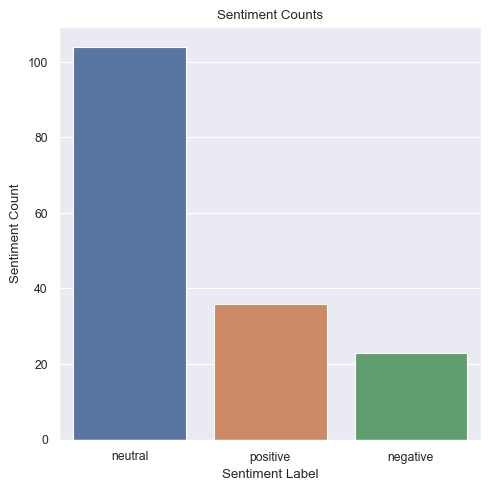

In [57]:
sns.set_theme('paper')
plt.figure(figsize= (5, 5))

sns.barplot(data= counts, x= 'label', y= 'count', hue= 'label')
plt.title('Sentiment Counts')
plt.xlabel('Sentiment Label')
plt.ylabel('Sentiment Count')

plt.tight_layout()
plt.show()

> With the graph and the two tables above, the number of lines of text that have been labeled as neutral, positive, and negative sentiments by the FinBERT model can be seen. Neutral lines of text make up the vast majority at 64% with a count of 104. Positive sentiments make up 22% of the lines of text, with a total count of 36. Negatively viewed lines of text make up the smallest grouping, with only 14% of all text being labeled by FinBERT as negative with a count of 23.

## **Quantify engagement frequency using Stakeholder keywords from KeyBERT:**

> For this analysis, the keywords from each line of text must be extracted from the model KeyBERT. Then, each line of text with keywords related to stakeholder engagement language will be extracted. Finally, the frequencies of each keyword and also the frequencies of sentiments (positive, negative, neutral) for each of line of text containing stakeholder keywords will be received.

In [58]:
model = KeyBERT()
keywords = model.extract_keywords(df['text'].tolist())

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

> The lines of text from the 10-K filing have been fit to the KeyBERT model and the keywords of each line have been extracted. There are a total of 5 different keywords extracted for each line of text.

In [59]:
keyword0 = []
keyword1 = []
keyword2 = []
keyword3 = []
keyword4 = []

for i in range(len(keywords)):
    keyword0.append(keywords[i][0][0])
    keyword1.append(keywords[i][1][0])
    keyword2.append(keywords[i][2][0])
    keyword3.append(keywords[i][3][0])
    keyword4.append(keywords[i][4][0])

df['Keyword 0'] = keyword0
df['Keyword 1'] = keyword1
df['Keyword 2'] = keyword2
df['Keyword 3'] = keyword3
df['Keyword 4'] = keyword4

df

,text,label,score,Keyword 0,Keyword 1,Keyword 2,Keyword 3,Keyword 4
0,We are focused on bringing artificial intellig...,neutral,0.497671,robotaxi,robots,ai,optimus,vehicles
1,Our mission is building a world of amazing abu...,positive,0.836269,mission,ai,business,engineering,advancements
2,We operate as two reportable segments: (i) aut...,neutral,0.946991,automotive,segments,energy,storage,reportable
3,"The automotive segment includes the design, de...",neutral,0.947820,automotive,vehicles,revenue,sales,leasing
4,We currently manufacture five different consum...,neutral,0.897390,suv,truck,vehicle,vehicles,tesla
...,...,...,...,...,...,...,...,...
158,Our cash flows from operating activities are s...,negative,0.665048,cash,investments,financings,expenses,payments
159,Net cash provided by operating activities decr...,negative,0.974064,income,cash,expenses,losses,liabilities
160,Net cash flows from investing activities and t...,neutral,0.883948,investments,expenditures,investing,billion,cash
161,Net cash flows from financing activities decre...,negative,0.974100,debt,repayments,financing,cash,decrease


> The 5 keywords for each line of text have been compiled and added to the dataframe. The first column of keywords are the most important and best describe each line of text.

In [60]:
counts = df['Keyword 0'].value_counts().reset_index().head(20)
counts

,Keyword 0,count
0,revenue,8
1,automotive,6
2,tesla,6
3,expense,5
4,robotaxi,4
5,regulations,4
6,superchargers,3
7,tax,3
8,manufacturing,3
9,solar,3


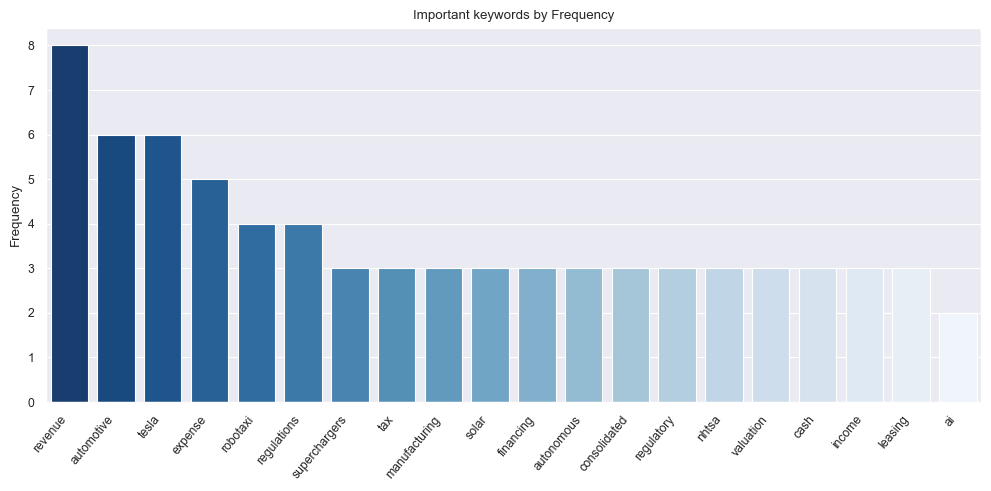

In [61]:
sns.set_theme('paper')
plt.figure(figsize= (10, 5))

sns.barplot(data= counts, x= 'Keyword 0', y= 'count', hue= 'Keyword 0', palette='Blues_r')
plt.title('Important keywords by Frequency')
plt.xlabel('')
plt.xticks(rotation= 50, ha= 'right')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

> This is a quick analysis showing the counts of the most common keywords within the first column (keyords 0). The most frequent keyword is revenue at 8 references, followed by automotive at 6 and tesla also at 6. The graph above, as well as the table both show this information.

In [62]:
shareholder_keywords = [
    'shareholder',
    'shareholders',
    'investor',
    'investors',
    'stockholder',
    'stockholders',
    'share',
    'owner',
    'ownership',
    'engagement',
    'engaged',
    'relations',
    'relationship',
    'meeting',
    'annual',
    'general',
    'communication',
    'communications',    
    'concerns',
    'concerned',
    'interests',
    'interesting',
    'value',
    'values',
    'return',
    'returns',
    'rights',
    'right',
    'proposals',
    'proposal',
    'proxy',
    'statement',
    'statements',
    'solicitation',
    'solicit',
    'institutional',
    'institution',
    'retail',
    'retailer',
    'engagement',
    'engage',
    'communication',
    'communications',
    'dialogue',
    'feedback',
    'outreach',
    'meeting',
    'meetings',
    'discussion',
    'discussions',
    'consultation',
    'consult',
    'contact',
    'contacts',
    'correspondence',
    'relationship',
    'relationships',
    'solicit',
    'solicitation',
    'vote',
    'voting',
    'shareholder',
    'shareholders',
    'stockholder',
    'stockholders',
    'investor',
    'investors',
    'institutional investor',
    'institutional investors',
    'retail investor',
    'retail investors',
    'beneficial owner',
    'beneficial owners'
]

> Now the focus is on the lines of text that are summarized using stakeholder language keywords. This list displays each word and term which can be  stakeholder engagement keywords. The list will be used to filter out any lines of text where the keywords are not related to stakeholder engagement language.
>
> NOTE: This list was generated by ChatGPT.

In [63]:
stakeholder = df[(df['Keyword 0'].isin(shareholder_keywords)) | (df['Keyword 1'].isin(shareholder_keywords)) | (df['Keyword 2'].isin(shareholder_keywords)) | (df['Keyword 3'].isin(shareholder_keywords)) | (df['Keyword 4'].isin(shareholder_keywords))]
stakeholder

,text,label,score,Keyword 0,Keyword 1,Keyword 2,Keyword 3,Keyword 4
42,"Globally, the ownership of our products by our...",neutral,0.888981,regulations,incentives,customers,ownership,jurisdictions
44,", to the consolidated financial statements inc...",neutral,0.946417,consolidated,financial,form,annual,10
76,We file or furnish periodic reports and amendm...,neutral,0.953898,quarterly,reports,sec,annual,form
77,") that contains reports, proxy and information...",neutral,0.948726,electronically,website,file,proxy,reports
78,", and our reports, amendments thereto, proxy s...",neutral,0.951088,investor,reports,website,free,amendments
79,as soon as reasonably practicable after we ele...,neutral,0.952276,sec,electronically,annual,incorporated,form
85,"In 2025, we recognized total revenues of $94.8...",positive,0.900915,revenues,revenue,income,profits,stockholders
109,The fair value of restricted stock granted to ...,neutral,0.948703,valuation,discount,ceo,stock,value
142,", to the consolidated financial statements inc...",neutral,0.946417,consolidated,financial,form,annual,10
145,", to the consolidated financial statements inc...",neutral,0.946417,consolidated,financial,form,annual,10


> These are the lines of text identified to contain stakeholder keywords.

In [64]:
counts = stakeholder['label'].value_counts().reset_index()
counts

,label,count
0,neutral,9
1,positive,1
2,negative,1


In [65]:
stakeholder['label'].value_counts(normalize= True).reset_index()

,label,proportion
0,neutral,0.818182
1,positive,0.090909
2,negative,0.090909


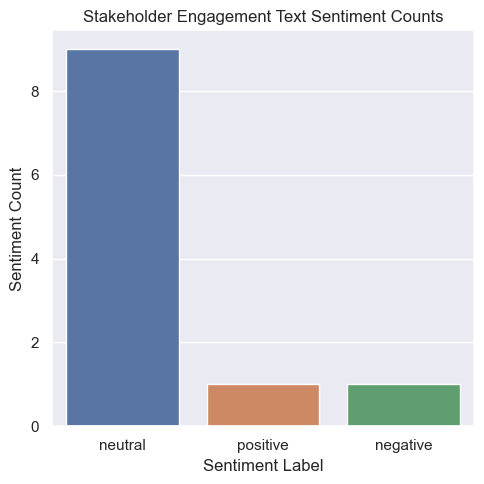

In [66]:
sns.set_theme('notebook')
plt.figure(figsize= (5, 5))

sns.barplot(data= counts, x= 'label', y= 'count', hue= 'label')
plt.title('Stakeholder Engagement Text Sentiment Counts')
plt.xlabel('Sentiment Label')
plt.ylabel('Sentiment Count')

plt.tight_layout()
plt.show()

> From the graph and the two tables above, it is clear that almost all of the text related to stakeholder engagement is neutral. Neutrality makes up 82% of the text with a count of 9, while positive text makes up only 1 of the lines of text, as does negative sentiment.

In [67]:
stakeholder[stakeholder['label'] == 'positive']['text'].tolist()

['In 2025, we recognized total revenues of $94.83 billion, representing a decrease of $2.86 billion compared to the prior year. In 2025, our net income attributable to common stockholders was $3.79 billion, representing a decrease of $3.30 billion compared to the prior year. We continue to ramp production and build and optimize our manufacturing capacity, expand our operations while focusing on further cost reductions and operational efficiencies to enable increased deliveries and deployments of our products, and invest in research and development to accelerate our AI, software and fleet-based profits for further revenue growth.']

> The one single positive text is: "In 2025, we recognized total revenues of $94.83 billion, representing a decrease of $2.86 billion compared to the prior year. In 2025, our net income attributable to common stockholders was $3.79 billion, representing a decrease of $3.30 billion compared to the prior year. We continue to ramp production and build and optimize our manufacturing capacity, expand our operations while focusing on further cost reductions and operational efficiencies to enable increased deliveries and deployments of our products, and invest in research and development to accelerate our AI, software and fleet-based profits for further revenue growth." The reason this text is positive is because it takes a very negative concept which is a decrease in total revenue by $2.86 billion, but then states how the company is fixing it by ramping production and optimizing  manufacturing capacity.

In [68]:
stakeholder[stakeholder['label'] == 'negative']['text'].tolist()

[', to the consolidated financial statements included elsewhere in this Annual Report on Form 10-K for further details regarding our debt obligations. Additionally, the decrease was partially offset by a $277 million decrease in principal payments on finance leases, a $133 million decrease in payments for buy-outs of noncontrolling interests in subsidiaries and $101 million of proceeds received from directors in shareholder settlement net of payment for related legal fees during the year ended December 31, 2025.']

> The negative text is: "to the consolidated financial statements included elsewhere in this Annual Report on Form 10-K for further details regarding our debt obligations. Additionally, the decrease was partially offset by a $277 million decrease in principal payments on finance leases, a $133 million decrease in payments for buy-outs of non-controlling interests in subsidiaries and $101 million of proceeds received from directors in shareholder settlement net of payment for related legal fees during the year ended December 31, 2025." The reason this line of text is entirely negative is because it discusses a decrease in principal payments on finance leases, and a decrease in payments for buy-outs of non-controlling interests in subsidiaries.

In [69]:
stakeholder_keywords = pd.concat([stakeholder['Keyword 0'], stakeholder['Keyword 1'], stakeholder['Keyword 2'], stakeholder['Keyword 3'], stakeholder['Keyword 4']])

stakeholder_keywords = stakeholder_keywords.reset_index()
stakeholder_keywords = stakeholder_keywords.drop(labels= 'index', axis= 1)
stakeholder_keywords['words'] = stakeholder_keywords[0]
stakeholder_keywords = stakeholder_keywords.drop(labels= 0, axis= 1)

> The next analysis that will be conducted is to determine stakeholder engagement frequency using the keywords extracted. To do this, each of the 5 different keyword columns are combined, and the word frequencies will be extracted. This will be the analysis stated in the title; "Quantify engagement frequency using Stakeholder keywords from KeyBERT". The above analysis is a form of sentiment analysis using keywords.

In [70]:
counts = stakeholder_keywords['words'].value_counts().reset_index().head(10)
counts

,words,count
0,annual,5
1,form,5
2,consolidated,3
3,financial,3
4,10,3
5,reports,3
6,electronically,2
7,sec,2
8,website,2
9,regulations,1


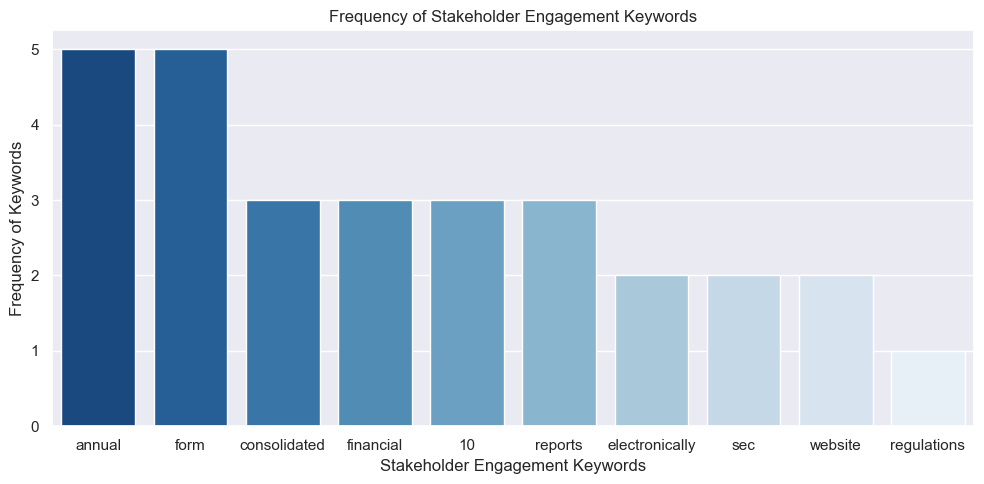

In [71]:
sns.set_theme('notebook')
plt.figure(figsize= (10, 5))

sns.barplot(data= counts, x= 'words', y= 'count', palette= 'Blues_r')
plt.title('Frequency of Stakeholder Engagement Keywords')
plt.xlabel('Stakeholder Engagement Keywords')
plt.ylabel('Frequency of Keywords')

plt.tight_layout()
plt.show()

> The stakeholder engagement keyword with the highest frequency of appearing in all 5 columns is annual with a count of 5. The second most frequent keyword is "form" which also appears 5 times in each of the keyword columns. The third most frequent keywords are consolidate, finance, and reports. These each have a frequency count of 3.